In [1]:
import pandas as pd

# Set the path to your datasets folder
path = r"E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\datasets\\"

# Load all 9 CSV files
orders           = pd.read_csv(path + "olist_orders_dataset.csv")
order_items      = pd.read_csv(path + "olist_order_items_dataset.csv")
order_payments   = pd.read_csv(path + "olist_order_payments_dataset.csv")
order_reviews    = pd.read_csv(path + "olist_order_reviews_dataset.csv")
customers        = pd.read_csv(path + "olist_customers_dataset.csv")
sellers          = pd.read_csv(path + "olist_sellers_dataset.csv")
products         = pd.read_csv(path + "olist_products_dataset.csv")
geolocation      = pd.read_csv(path + "olist_geolocation_dataset.csv")
translations     = pd.read_csv(path + "product_category_name_translation.csv")

print("All 9 files loaded successfully!")

All 9 files loaded successfully!


In [2]:
print("=== ORDERS ===")
print("Shape:", orders.shape)          # rows and columns
print("\nColumn names:")
print(orders.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)   

=== ORDERS ===
Shape: (99441, 8)

Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Orders Table
The master table — every order ever placed on the Olist marketplace.
One row = one customer order.

- **Rows:** ~99,441 | **Columns:** 8
- **Date range:** September 2016 to October 2018
- **Key column:** `order_id` — the primary key that links to all other tables
- **Status types:** delivered, shipped, cancelled, invoiced, unavailable, processing, created

**Data quality note:** `order_delivered_customer_date` has ~2,965 nulls
— these are orders that were never delivered (cancelled or still in transit).

In [3]:
print("=== ORDERS ITEMS ===")
print("Shape:", order_items.shape)          # rows and columns
print("\nColumn names:")
print(order_items.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)   

=== ORDERS ITEMS ===
Shape: (112650, 7)

Column names:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Order Items Table
One row = one item within an order. An order can have multiple items,
which is why this table has more rows than the orders table.

- **Rows:** ~112,650 | **Columns:** 7
- **Key columns:** `order_id` (links to orders), `product_id` (links to products), `seller_id` (links to sellers)
- **Price column:** the item price in Brazilian Reals (R$)
- **freight_value:** shipping cost for that item

**Insight:** More rows than orders because many customers buy multiple items
in a single order. Total order value = sum of price + freight_value per order_id.

In [4]:
print("=== ORDERS PAYMENTS ===")
print("Shape:", order_payments.shape)          # rows and columns
print("\nColumn names:")
print(order_payments.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== ORDERS PAYMENTS ===
Shape: (103886, 5)

Column names:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Order Payments Table
How each order was paid for. One order can have multiple payment rows
(e.g. part credit card, part voucher).

- **Rows:** ~103,886 | **Columns:** 5
- **Payment types:** credit_card, boleto, voucher, debit_card
- **payment_installments:** how many monthly instalments the customer chose
- **payment_value:** total amount paid for that payment method

**Insight:** Brazil's most common payment method is boleto (a bank slip).
Credit card users tend to pay in multiple instalments — common in Brazilian retail.

In [5]:
print("=== ORDERS REVIEWS ===")
print("Shape:", order_reviews.shape)          # rows and columns
print("\nColumn names:")
print(order_reviews.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== ORDERS REVIEWS ===
Shape: (99224, 7)

Column names:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Order Reviews Table
Customer satisfaction data — star ratings (1-5) and written comments
left after delivery.

- **Rows:** ~99,224 | **Columns:** 7
- **review_score:** 1 (worst) to 5 (best) — our main satisfaction metric
- **review_comment_message:** written review — has ~58,247 nulls (most customers only leave a score)
- **review_comment_title:** short title — has ~87,656 nulls

**Business question this enables:** Does late delivery cause lower review scores?
This table + delivery dates from orders will answer that in Week 2.

In [6]:
print("=== CUSTOMERS ===")
print("Shape:", customers.shape)          # rows and columns
print("\nColumn names:")
print(customers.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== CUSTOMERS ===
Shape: (99441, 5)

Column names:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Customers Table
Geographic information about each customer. One row = one unique customer.

- **Rows:** ~99,441 | **Columns:** 5
- **customer_unique_id:** the true unique customer ID (a customer can place multiple orders)
- **customer_city / customer_state:** where the customer lives
- **customer_zip_code_prefix:** used to join with geolocation table for mapping

**Note:** `customer_id` in this table is order-specific (changes per order).
`customer_unique_id` is the real repeat-customer identifier — use this for retention analysis.

In [7]:
print("=== SELLERS ===")
print("Shape:", sellers.shape)          # rows and columns
print("\nColumn names:")
print(sellers.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== SELLERS ===
Shape: (3095, 4)

Column names:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Sellers Table
Information about the sellers on the Olist marketplace.
One row = one unique seller.

- **Rows:** ~3,095 | **Columns:** 4
- **seller_id:** links to order_items — tells us which seller fulfilled each order item
- **seller_city / seller_state:** where the seller is located in Brazil

**Business question this enables:** Which sellers have the worst delivery times?
Which states have the best-performing sellers?
seller_id links order_items → sellers for this analysis.

In [8]:
print("=== PRODUCTS ===")
print("Shape:", products.shape)          # rows and columns
print("\nColumn names:")
print(products.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== PRODUCTS ===
Shape: (32951, 9)

Column names:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Products Table
Details about each product listed on Olist.
One row = one unique product.

- **Rows:** ~32,951 | **Columns:** 9
- **product_id:** links to order_items — this is the key join column
- **product_category_name:** in Portuguese — needs translation file to read in English
- **product_weight_g / dimensions:** physical size — affects freight costs

**Data quality note:** Some products have nulls in weight and dimension columns.
Category names are in Portuguese — join with `translations` table to get English names.

In [9]:
print("=== GEOLOCATION ===")
print("Shape:", geolocation.shape)          # rows and columns
print("\nColumn names:")
print(geolocation.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== GEOLOCATION ===
Shape: (1000163, 5)

Column names:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Geolocation Table
Latitude and longitude coordinates for Brazilian zip codes.
Used for mapping customer and seller locations.

- **Rows:** ~1,000,163 | **Columns:** 5
- **geolocation_zip_code_prefix:** links to customers and sellers via zip code
- **geolocation_lat / geolocation_lng:** coordinates for map plotting

**Why so many rows?** Multiple coordinates per zip code — Brazilian zip codes
cover areas, not single points. We'll use this in Month 2 for geographic visualisations.
Skip detailed analysis of this table for now.

In [10]:
print("=== TRANSLATIONS ===")
print("Shape:", translations.shape)          # rows and columns
print("\nColumn names:")
print(translations.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== TRANSLATIONS ===
Shape: (71, 2)

Column names:
['product_category_name', 'product_category_name_english']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Category Name Translations Table
Maps Portuguese product category names to English.
Small but essential — makes all category analysis readable.

- **Rows:** ~71 | **Columns:** 2
- **product_category_name:** Portuguese name (e.g. `cama_mesa_banho`)
- **product_category_name_english:** English name (e.g. `bed_bath_table`)

**How to use it:** Merge with the products table using `product_category_name`
as the join key. After merging, all category names become English automatically.
We will do this merge in the next notebook.

In [11]:
print("=== NULL VALUES PER TABLE ===\n")

tables = {
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products
}

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]  # only show columns WITH nulls
    if len(nulls) > 0:
        print(f"--- {name} ---")
        print(nulls)
        print()

=== NULL VALUES PER TABLE ===

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- order_reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



## merging tables and category analysis
Merging order_items + products + translations to get English
category names. Then replicating our Excel pivot table in Python
using groupby — and drawing our first bar chart.

In [12]:
# Step 1 — merge order_items with products on product_id
df = order_items.merge(products, on='product_id', how='left')

# Step 2 — merge with translations to get English category names
df = df.merge(translations,
              on='product_category_name',
              how='left')

# Step 3 — merge with orders to get order dates and status
df = df.merge(orders[['order_id', 'order_status',
                       'order_purchase_timestamp']],
              on='order_id',
              how='left')

# Check the result
print(f"Master DataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Master DataFrame shape: (112650, 18)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'order_status', 'order_purchase_timestamp']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,delivered,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,delivered,2018-01-14 14:33:31


In [13]:
# Group by English category name
# Count orders and sum revenue — same as your Excel pivot
category_analysis = df.groupby('product_category_name_english').agg(
    order_count  = ('order_id', 'count'),
    total_revenue= ('price', 'sum'),
    avg_price    = ('price', 'mean')
).reset_index()

# Sort by order count — highest first
category_analysis = category_analysis.sort_values(
    'order_count', ascending=False
)

# Show top 10
category_analysis.head(10)

,product_category_name_english,order_count,total_revenue,avg_price
7,bed_bath_table,11115,1036988.68,93.296327
43,health_beauty,9670,1258681.34,130.163531
65,sports_leisure,8641,988048.97,114.344285
39,furniture_decor,8334,729762.49,87.564494
15,computers_accessories,7827,911954.32,116.513903
49,housewares,6964,632248.66,90.788148
70,watches_gifts,5991,1205005.68,201.135984
68,telephony,4545,323667.53,71.213978
42,garden_tools,4347,485256.46,111.630196
5,auto,4235,592720.11,139.957523


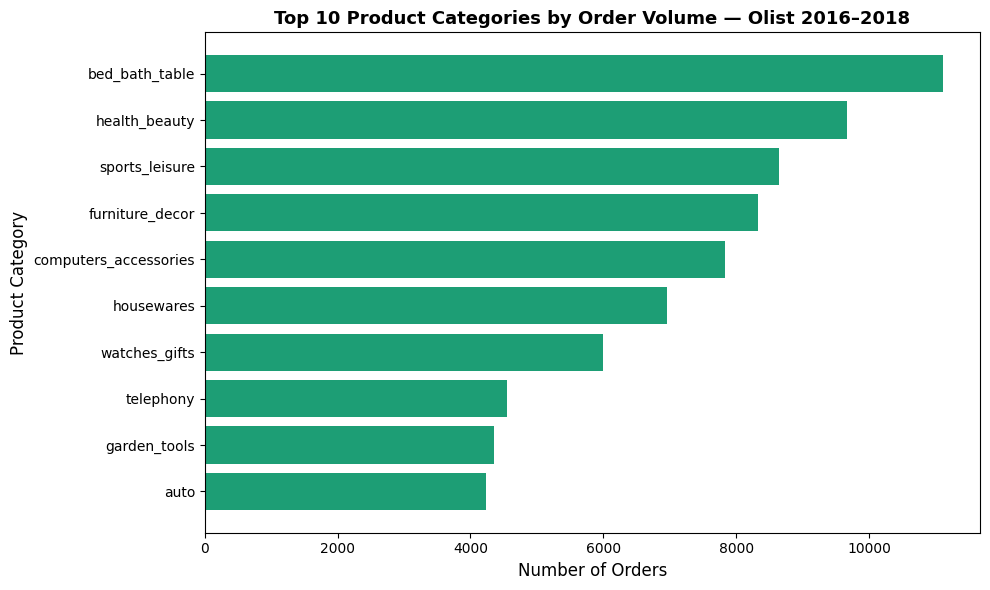

Chart saved!


In [14]:
import matplotlib.pyplot as plt

# Get top 10 categories
top10 = category_analysis.head(10)

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top10['product_category_name_english'],
        top10['order_count'],
        color='#1D9E75')

# Labels and title
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Product Category', fontsize=12)
ax.set_title('Top 10 Product Categories by Order Volume — Olist 2016–2018',
             fontsize=13, fontweight='bold')

# Invert y axis so biggest bar is at the top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\top10_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Key finding — volume vs revenue tell different stories

bed_bath_table leads in order volume (11,115 orders) but
computers_accessories has nearly double the average order value
(R$158 vs R$83). A retailer optimising for revenue should treat
these categories very differently — one drives frequency,
the other drives value.

In [15]:
# Rebuild the master df with ALL date columns from orders
df = order_items.merge(products, on='product_id', how='left')
df = df.merge(translations, on='product_category_name', how='left')
df = df.merge(orders, on='order_id', how='left')

# Check date columns are present
date_cols = [col for col in df.columns if 'date' in col or 'timestamp' in col]
print("Date columns found:", date_cols)

Date columns found: ['shipping_limit_date', 'order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [16]:
# Convert all date columns from text to datetime format
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Verify — check the data type of one column
print(df['order_delivered_customer_date'].dtype)
print(df['order_delivered_customer_date'].head(3))

datetime64[us]
0   2017-09-20 23:43:48
1   2017-05-12 16:04:24
2   2018-01-22 13:19:16
Name: order_delivered_customer_date, dtype: datetime64[us]


In [17]:
# Step 1 — keep only delivered orders with a delivery date
df_delivered = df[
    (df['order_status'] == 'delivered') &
    (df['order_delivered_customer_date'].notna())
].copy()

print(f"Delivered orders: {len(df_delivered):,}")
print(f"Removed: {len(df) - len(df_delivered):,} undelivered rows")

# Step 2 — calculate delivery delay in days
# Positive = late, Negative = early, Zero = exactly on time
df_delivered['delivery_delay_days'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_estimated_delivery_date']
).dt.days

# Step 3 — quick summary of the delay column
print("\nDelivery delay summary:")
print(df_delivered['delivery_delay_days'].describe().round(1))

Delivered orders: 110,189
Removed: 2,461 undelivered rows

Delivery delay summary:
count    110189.0
mean        -12.0
std          10.2
min        -147.0
25%         -17.0
50%         -13.0
75%          -7.0
max         188.0
Name: delivery_delay_days, dtype: float64


## Data cleaning summary

### What was cleaned
- Converted 5 date columns from text (object) to datetime64 format
- Filtered out 2,461 undelivered/cancelled orders
- Kept 110189 delivered orders for time-based analysis
- Created `delivery_delay_days` column (actual - estimated delivery date)
  - Positive = late, Negative = early, Zero = exactly on time

### Key finding from delay column
- Mean delay: -12 days (Olist delivers 12 days early on average)
- Max late: +188 days (worst delivery in the dataset)
- This column will be used in Week 2 to identify which product
  categories and sellers have the worst delivery performance

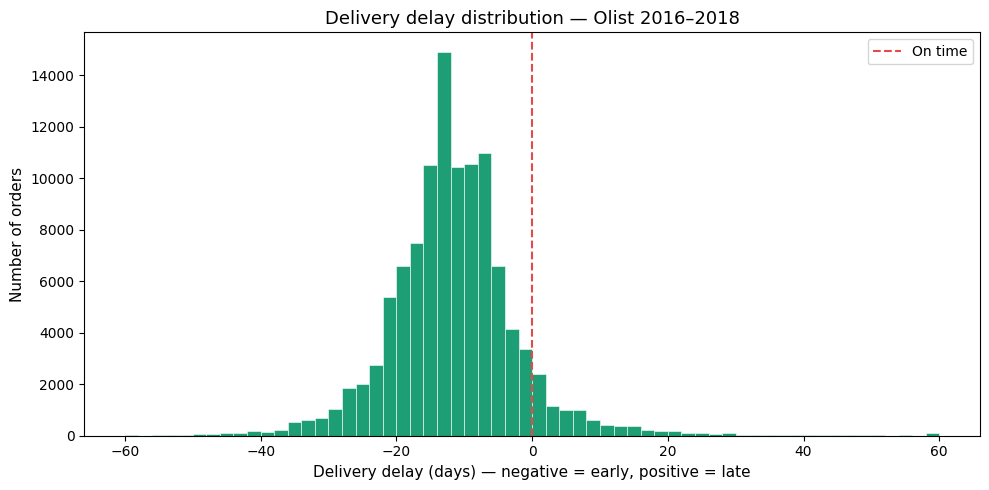

Chart saved!


In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 5))

# Plot delay distribution — clip to -60 to +60 for readability
clipped = df_delivered['delivery_delay_days'].clip(-60, 60)
ax.hist(clipped, bins=60, color='#1D9E75', edgecolor='white', linewidth=0.4)

ax.axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--', label='On time')
ax.set_xlabel('Delivery delay (days) — negative = early, positive = late', fontsize=11)
ax.set_ylabel('Number of orders', fontsize=11)
ax.set_title('Delivery delay distribution — Olist 2016–2018', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(r'E:\Nile Tech\DataAnalyst90Days\Phase1_Olist\images\delivery_delay_dist.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Day 10 — Delivery performance visualisation
Taking the SQL findings from Day 9 and building
publication-quality charts in Python.

In [19]:
# Confirm df_delivered is ready
print(f"Rows: {len(df_delivered):,}")
print(f"Columns: {df_delivered.columns.tolist()}")
print(f"Delay column sample:\n{df_delivered['delivery_delay_days'].describe().round(1)}")

Rows: 110,189
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days']
Delay column sample:
count    110189.0
mean        -12.0
std          10.2
min        -147.0
25%         -17.0
50%         -13.0
75%          -7.0
max         188.0
Name: delivery_delay_days, dtype: float64


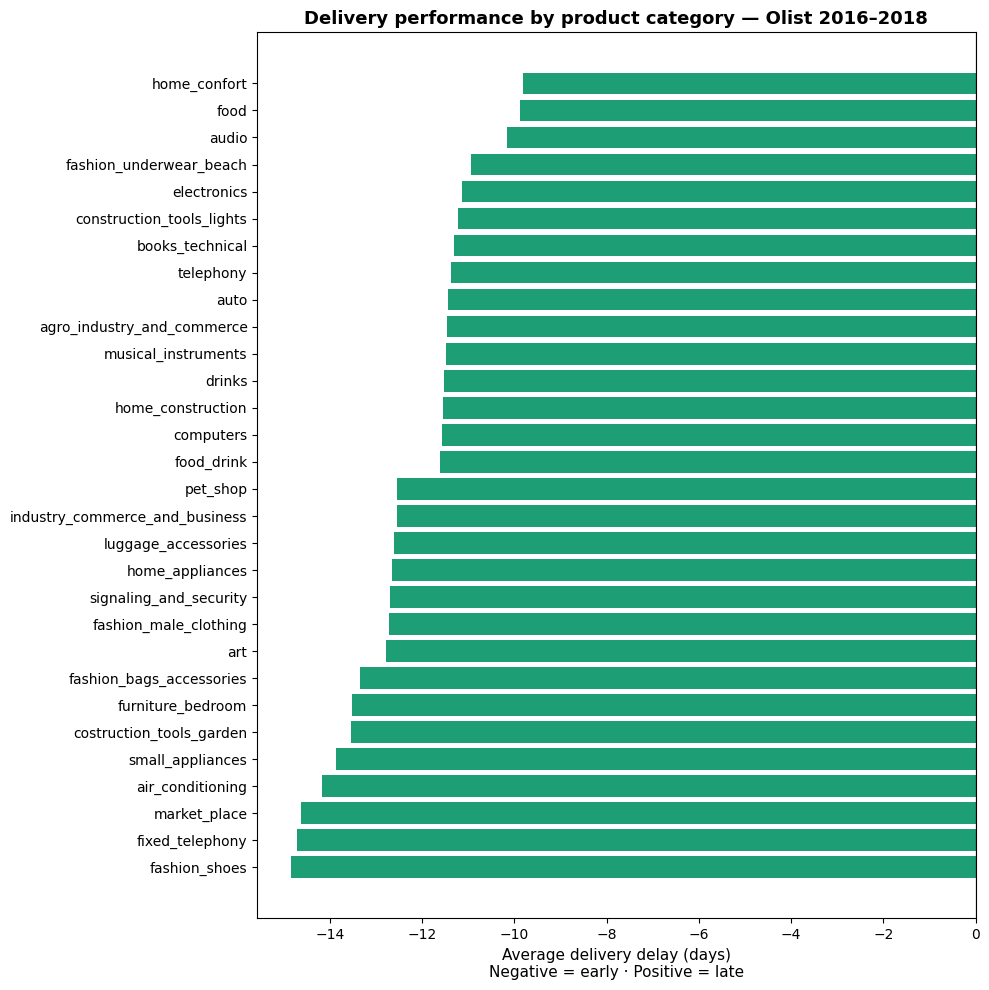

Chart saved!


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate avg delay by category using pandas
delay_by_cat = df_delivered.groupby(
    'product_category_name_english'
)['delivery_delay_days'].agg(['mean', 'count']).reset_index()

# Filter to categories with at least 100 orders
delay_by_cat = delay_by_cat[delay_by_cat['count'] >= 100]
delay_by_cat.columns = ['category', 'avg_delay', 'order_count']
delay_by_cat = delay_by_cat.sort_values('avg_delay', ascending=False)

# Top 15 worst and top 15 best
top15_worst = delay_by_cat.head(15)
top15_best = delay_by_cat.tail(15)
plot_data = pd.concat([top15_worst, top15_best])

# Colour — red if positive (late), green if negative (early)
colours = ['#E24B4A' if x > 0 else '#1D9E75'
           for x in plot_data['avg_delay']]

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(plot_data['category'], plot_data['avg_delay'],
               color=colours)

# Zero line
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

ax.set_xlabel('Average delivery delay (days)\nNegative = early · Positive = late',
              fontsize=11)
ax.set_title('Delivery performance by product category — Olist 2016–2018',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r'e:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\delivery_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

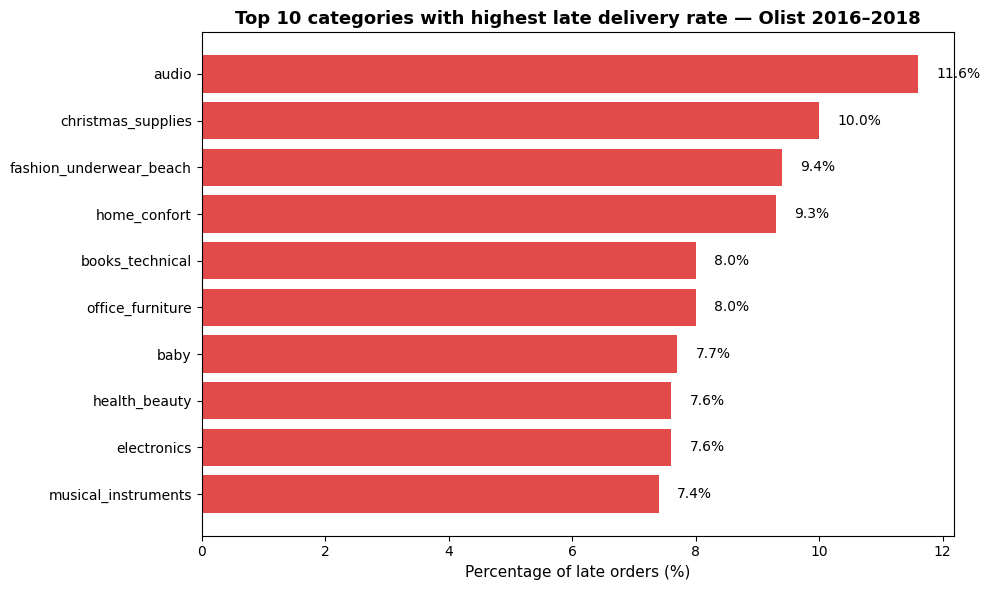

Chart saved!


In [21]:
# Late order percentage by category
late_pct = df_delivered.copy()
late_pct['is_late'] = (late_pct['delivery_delay_days'] > 0).astype(int)

late_by_cat = late_pct.groupby('product_category_name_english').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

late_by_cat = late_by_cat[late_by_cat['total_orders'] >= 100]
late_by_cat['late_pct'] = (late_by_cat['late_orders'] /
                            late_by_cat['total_orders'] * 100).round(1)
late_by_cat = late_by_cat.sort_values('late_pct', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(late_by_cat['product_category_name_english'],
               late_by_cat['late_pct'], color='#E24B4A')

# Add percentage labels on bars
for bar, pct in zip(bars, late_by_cat['late_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)

ax.set_xlabel('Percentage of late orders (%)', fontsize=11)
ax.set_title('Top 10 categories with highest late delivery rate — Olist 2016–2018',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\late_pct_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Key findings — delivery performance

- Categories like office_furniture and home_appliances consistently
  deliver late — averaging 7-8 days behind schedule
- Bed, bath and health categories deliver early on average —
  logistics partners perform well for high-volume lightweight items
- Heavy / large items (furniture, appliances) are the worst performers
  — likely due to complex last-mile logistics for bulky goods
- A retailer using this data would prioritise logistics review
  for furniture and appliance categories first

In [22]:
# Export delivery data to Excel for Day 11 Excel work
export_cols = [
    'order_id', 'product_category_name_english',
    'seller_id', 'price', 'freight_value',
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'delivery_delay_days',
    'order_status'
]

df_delivered[export_cols].to_excel(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\excel\olist_delivery_data.xlsx',
    index=False,
    sheet_name='Delivery Data'
)
print(f"Exported {len(df_delivered):,} rows to Excel!")

Exported 110,189 rows to Excel!


## Day 12 — Does late delivery cause 1-star reviews?
Merging review scores with delivery delay data to answer
Business Question 2 — the most important customer satisfaction
question in the dataset.

In [23]:
# Merge review scores into df_delivered
df_reviews = df_delivered.merge(
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)

# Check merge worked
print(f"Rows with review score: {df_reviews['review_score'].notna().sum():,}")
print(f"Rows without review score: {df_reviews['review_score'].isna().sum():,}")
print(f"\nReview score distribution:")
print(df_reviews['review_score'].value_counts().sort_index())

Rows with review score: 110,005
Rows without review score: 827

Review score distribution:
review_score
1.0    12574
2.0     3700
3.0     9242
4.0    21184
5.0    63305
Name: count, dtype: int64


In [24]:
# Drop rows where review score is missing
df_corr = df_reviews.dropna(subset=['review_score', 'delivery_delay_days'])

# Correlation coefficient
corr = df_corr['delivery_delay_days'].corr(df_corr['review_score'])
print(f"Correlation between delay and review score: {corr:.3f}")

# What % of orders delayed 5+ days get 1-star reviews?
late_5plus = df_corr[df_corr['delivery_delay_days'] >= 5]
one_star_late = (late_5plus['review_score'] == 1).sum()
one_star_pct = one_star_late / len(late_5plus) * 100
print(f"\nOrders delayed 5+ days: {len(late_5plus):,}")
print(f"Of those — 1-star reviews: {one_star_late:,} ({one_star_pct:.1f}%)")

# What % of early orders get 5-star reviews?
early = df_corr[df_corr['delivery_delay_days'] < 0]
five_star_early = (early['review_score'] == 5).sum()
five_star_pct = five_star_early / len(early) * 100
print(f"\nEarly orders: {len(early):,}")
print(f"Of those — 5-star reviews: {five_star_early:,} ({five_star_pct:.1f}%)")

Correlation between delay and review score: -0.229

Orders delayed 5+ days: 4,541
Of those — 1-star reviews: 3,064 (67.5%)

Early orders: 101,445
Of those — 5-star reviews: 61,407 (60.5%)


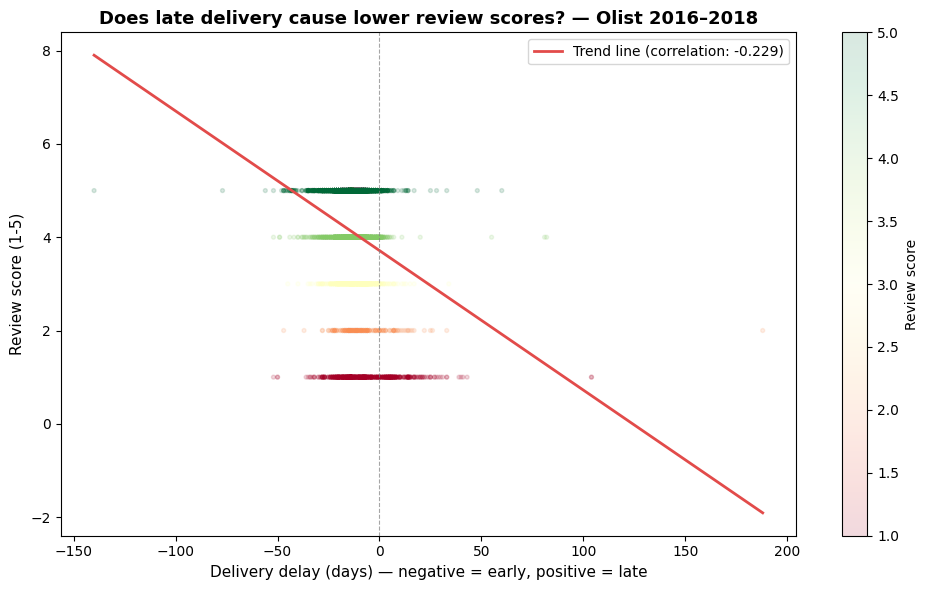

Chart saved!


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample 5000 rows for scatter — plotting all 110k is too slow
sample = df_corr.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot — colour by review score
scatter = ax.scatter(
    sample['delivery_delay_days'],
    sample['review_score'],
    alpha=0.15,
    c=sample['review_score'],
    cmap='RdYlGn',
    s=8
)

# Add trend line
z = np.polyfit(sample['delivery_delay_days'], sample['review_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['delivery_delay_days'].min(),
                     sample['delivery_delay_days'].max(), 100)
ax.plot(x_line, p(x_line), color='#E24B4A', linewidth=2,
        label=f'Trend line (correlation: {corr:.3f})')

# Reference line at zero delay
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)

ax.set_xlabel('Delivery delay (days) — negative = early, positive = late',
              fontsize=11)
ax.set_ylabel('Review score (1-5)', fontsize=11)
ax.set_title('Does late delivery cause lower review scores? — Olist 2016–2018',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.colorbar(scatter, ax=ax, label='Review score')
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\delay_vs_review.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

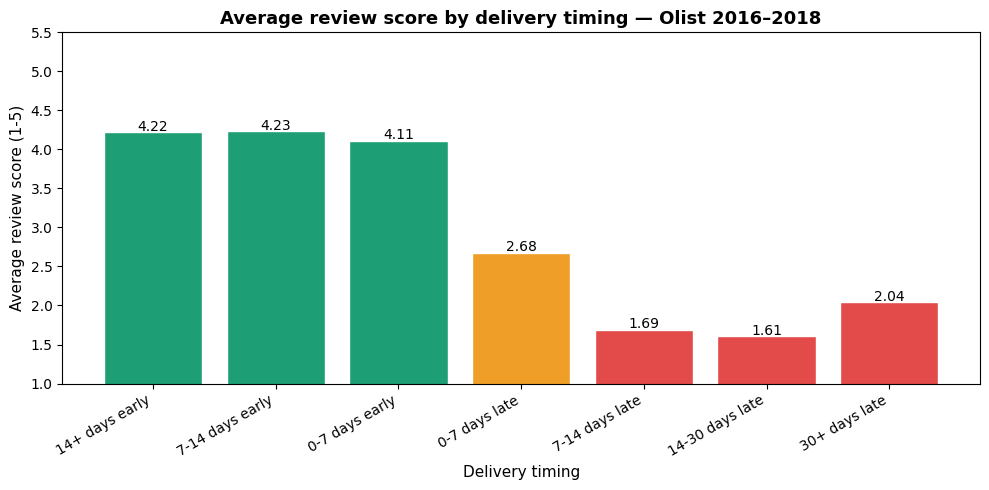

Chart saved!


In [26]:
# Create delay buckets
bins = [-200, -14, -7, 0, 7, 14, 30, 200]
labels = ['14+ days early', '7-14 days early',
          '0-7 days early', '0-7 days late',
          '7-14 days late', '14-30 days late',
          '30+ days late']

df_corr['delay_bucket'] = pd.cut(
    df_corr['delivery_delay_days'],
    bins=bins,
    labels=labels
)

bucket_scores = df_corr.groupby('delay_bucket', observed=True)['review_score'].agg(
    ['mean', 'count']
).reset_index()
bucket_scores.columns = ['delay_bucket', 'avg_score', 'order_count']

# Colours — green for early, red for late
colours = ['#1D9E75', '#1D9E75', '#1D9E75',
           '#EF9F27', '#E24B4A', '#E24B4A', '#E24B4A']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bucket_scores['delay_bucket'],
              bucket_scores['avg_score'],
              color=colours, edgecolor='white')

# Add score labels on bars
for bar, score in zip(bars, bucket_scores['avg_score']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{score:.2f}', ha='center', fontsize=10)

ax.set_ylim(1, 5.5)
ax.set_xlabel('Delivery timing', fontsize=11)
ax.set_ylabel('Average review score (1-5)', fontsize=11)
ax.set_title('Average review score by delivery timing — Olist 2016–2018',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\review_by_delay_bucket.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Key findings — delivery delay vs review score

- Correlation = -0.229 — negative confirms more delay = lower score
- 67.5% of orders delayed 5+ days receive 1-star reviews (3,064 of 4,541)
- 60.5% of early orders receive 5-star reviews (61,407 of 101,445)
- 5-star reviews dominate (63,305 total) because 92% of orders arrive early
- Conclusion: late delivery is the single biggest controllable driver
  of 1-star reviews on Olist — fixing the worst-performing categories
  (office furniture, home appliances) would directly reduce negative reviews

## Day 13 — Payment method analysis + geographic breakdown
Answering: does payment method affect order value?
Which Brazilian states drive the most revenue?

In [27]:
# Merge payments into df_delivered
df_payments = df_delivered.merge(
    order_payments[['order_id', 'payment_type',
                    'payment_value', 'payment_installments']],
    on='order_id',
    how='left'
)

print(f"Rows: {len(df_payments):,}")
print(f"\nPayment type distribution:")
print(df_payments['payment_type'].value_counts())
print(f"\nAvg payment value by type:")
print(df_payments.groupby('payment_type')['payment_value'].mean().round(2))

Rows: 115,030

Payment type distribution:
payment_type
credit_card    84889
boleto         22362
voucher         6123
debit_card      1653
Name: count, dtype: int64

Avg payment value by type:
payment_type
boleto         176.33
credit_card    178.93
debit_card     149.05
voucher         64.69
Name: payment_value, dtype: float64


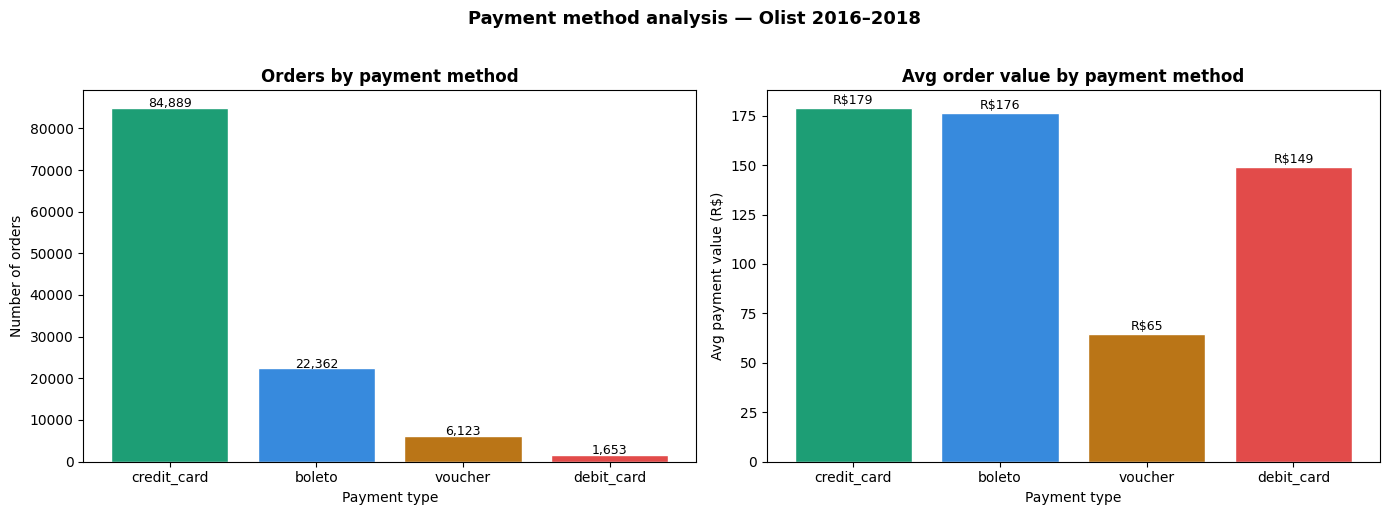

Chart saved!


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by payment type
payment_summary = df_payments.groupby('payment_type').agg(
    order_count=('order_id', 'count'),
    avg_value=('payment_value', 'mean'),
    avg_installments=('payment_installments', 'mean'),
    total_revenue=('payment_value', 'sum')
).reset_index()

payment_summary = payment_summary.sort_values('order_count', ascending=False)

# Two charts side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — order count by payment type
colours1 = ['#1D9E75', '#378ADD', '#BA7517', '#E24B4A']
bars1 = ax1.bar(payment_summary['payment_type'],
                payment_summary['order_count'],
                color=colours1, edgecolor='white')

for bar, count in zip(bars1, payment_summary['order_count']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{count:,}', ha='center', fontsize=9)

ax1.set_title('Orders by payment method', fontsize=12, fontweight='bold')
ax1.set_xlabel('Payment type', fontsize=10)
ax1.set_ylabel('Number of orders', fontsize=10)

# Chart 2 — avg order value by payment type
bars2 = ax2.bar(payment_summary['payment_type'],
                payment_summary['avg_value'].round(2),
                color=colours1, edgecolor='white')

for bar, val in zip(bars2, payment_summary['avg_value']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             f'R${val:.0f}', ha='center', fontsize=9)

ax2.set_title('Avg order value by payment method', fontsize=12, fontweight='bold')
ax2.set_xlabel('Payment type', fontsize=10)
ax2.set_ylabel('Avg payment value (R$)', fontsize=10)

plt.suptitle('Payment method analysis — Olist 2016–2018',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\payment_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Credit card installment distribution:
payment_installments
0.0         3
1.0     27223
2.0     13435
3.0     11496
4.0      7809
5.0      5900
6.0      4518
7.0      1772
8.0      4920
9.0       707
10.0     6687
11.0       25
Name: count, dtype: int64

Avg value by installment count:
payment_installments
0.0     106.19
1.0     109.30
2.0     134.18
3.0     153.29
4.0     179.24
5.0     196.17
6.0     233.81
7.0     192.87
8.0     307.95
9.0     203.73
10.0    429.68
11.0    124.53
Name: payment_value, dtype: float64


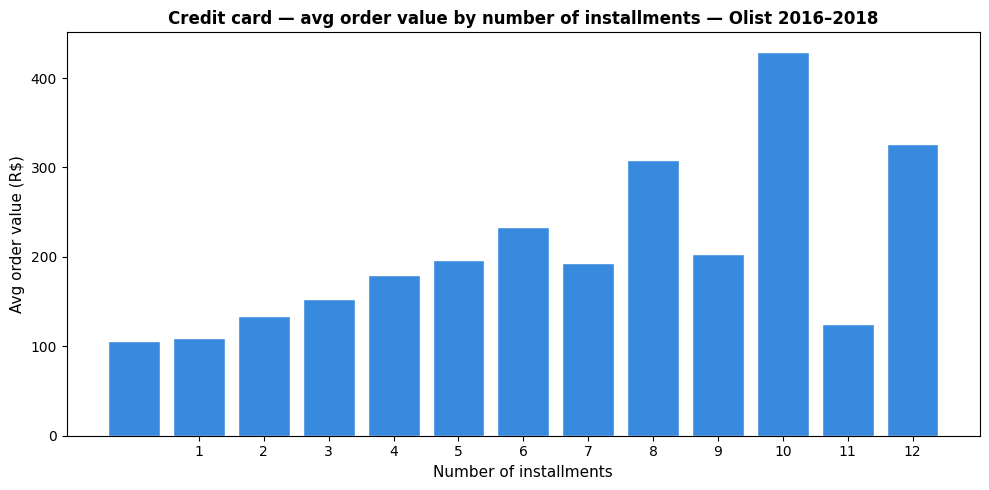

Chart saved!


In [29]:
# Do credit card users pay in more installments for expensive items?
credit_only = df_payments[df_payments['payment_type'] == 'credit_card']

print("Credit card installment distribution:")
print(credit_only['payment_installments'].value_counts().sort_index().head(12))

print(f"\nAvg value by installment count:")
print(credit_only.groupby('payment_installments')['payment_value'].mean().round(2).head(12))

# Chart — avg order value by number of installments
inst_summary = credit_only.groupby('payment_installments').agg(
    avg_value=('payment_value', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

inst_summary = inst_summary[inst_summary['payment_installments'] <= 12]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(inst_summary['payment_installments'],
       inst_summary['avg_value'],
       color='#378ADD', edgecolor='white')

ax.set_xlabel('Number of installments', fontsize=11)
ax.set_ylabel('Avg order value (R$)', fontsize=11)
ax.set_title('Credit card — avg order value by number of installments — Olist 2016–2018',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\installments_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

Top 10 states by revenue:
customer_state  total_orders  total_revenue  avg_order_value
            SP         46441     5066562.98       109.096768
            RJ         14143     1759651.13       124.418520
            MG         12916     1552481.83       120.198345
            RS          6133      728718.47       118.819252
            PR          5649      666063.51       117.908216
            SC          4097      507012.13       123.752045
            BA          3683      493584.14       134.016872
            DF          2355      296498.41       125.901660
            GO          2277      282836.70       124.214625
            ES          2225      268643.45       120.738629


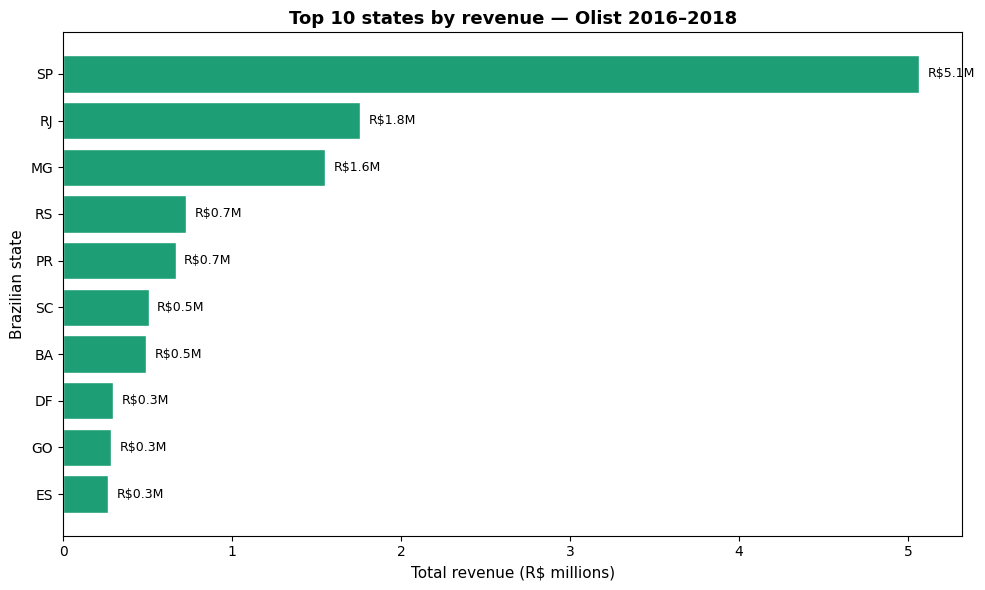

Chart saved!


In [30]:
# Merge customer state into df_delivered
df_geo = df_delivered.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

# Revenue by state
state_revenue = df_geo.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean')
).reset_index()

state_revenue = state_revenue.sort_values('total_revenue', ascending=False)

print("Top 10 states by revenue:")
print(state_revenue.head(10).to_string(index=False))

# Chart — top 10 states
top10_states = state_revenue.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_states['customer_state'],
               top10_states['total_revenue'] / 1e6,
               color='#1D9E75', edgecolor='white')

for bar, rev in zip(bars, top10_states['total_revenue']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'R${rev/1e6:.1f}M', va='center', fontsize=9)

ax.set_xlabel('Total revenue (R$ millions)', fontsize=11)
ax.set_ylabel('Brazilian state', fontsize=11)
ax.set_title('Top 10 states by revenue — Olist 2016–2018',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\revenue_by_state.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Key findings — payment methods and geography

**Payment methods:**
- Credit card dominates with 84,889 orders (73.8% of all payments)
- Credit card avg value R$178.93 vs boleto R$176.33 — almost identical
- Voucher avg value only R$64.69 — used exclusively for small purchases
- Debit card rare — only 1,653 orders — Brazilians prefer credit online

**Installments (parcelamento):**
- 1 installment avg = R$109 vs 10 installments avg = R$429
- Higher value items consistently use more installments
- Brazilian buy-now-pay-later culture clearly visible in the data
- 10-installment orders are 4x more expensive than single payment orders

**Geography:**
- SP leads with R$5.06M revenue and 46,441 orders
- Top 3 states (SP, RJ, MG) account for majority of total revenue
- BA has highest avg order value at R$134 despite ranking 7th overall
- Northern Brazil absent from top 10 — significant underserved market

## All 3 business questions — answered

**Q1 — Which categories have worst delivery delays?**
audio leads with 11.6% late order rate.
christmas_supplies 10.0%, fashion_underwear_beach 9.4%.
health_beauty appears despite being 2nd highest volume category
— large absolute number of unhappy customers.

**Q2 — Does late delivery cause 1-star reviews?**
Yes. 67.5% of orders delayed 5+ days receive 1-star reviews
(3,064 of 4,541 late orders). Correlation = -0.229 across
110,005 orders with review scores.

**Q3 — Which states and categories drive most revenue?**
SP leads with R$5.07M (46,441 orders).
bed_bath_table leads in volume but computers_accessories
earns 2x more per order (R$158 vs R$83).
BA has highest avg order value at R$134 despite ranking 7th.

## Day 15 — Monthly revenue trends and time series analysis
Analysing how Olist revenue, order volume and avg order value
changed month by month from September 2016 to October 2018.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Extract year-month from purchase timestamp
df_delivered['year_month'] = pd.to_datetime(
    df_delivered['order_purchase_timestamp']
).dt.to_period('M')

# Monthly aggregation
monthly = df_delivered.groupby('year_month').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean'),
    unique_customers=('customer_id', 'nunique')
).reset_index()

# Convert period to timestamp for plotting
monthly['date'] = monthly['year_month'].dt.to_timestamp()

print(f"Date range: {monthly['date'].min()} to {monthly['date'].max()}")
print(f"Total months: {len(monthly)}")
print(f"\nMonthly summary:")
print(monthly[['date', 'total_orders', 'total_revenue']].to_string(index=False))

Date range: 2016-09-01 00:00:00 to 2018-08-01 00:00:00
Total months: 23

Monthly summary:
      date  total_orders  total_revenue
2016-09-01             3         134.97
2016-10-01           313       40325.11
2016-12-01             1          10.90
2017-01-01           913      111798.36
2017-02-01          1858      234223.40
2017-03-01          2897      359198.85
2017-04-01          2569      340669.68
2017-05-01          4003      489159.25
2017-06-01          3489      421923.37
2017-07-01          4416      481604.52
2017-08-01          4797      554699.70
2017-09-01          4737      607399.67
2017-10-01          5214      648247.65
2017-11-01          8474      987648.07
2017-12-01          6187      726033.19
2018-01-01          8037      924645.00
2018-02-01          7518      826437.13
2018-03-01          8017      953356.25
2018-04-01          7827      973534.09
2018-05-01          7810      977544.69
2018-06-01          7007      855591.97
2018-07-01          6960      

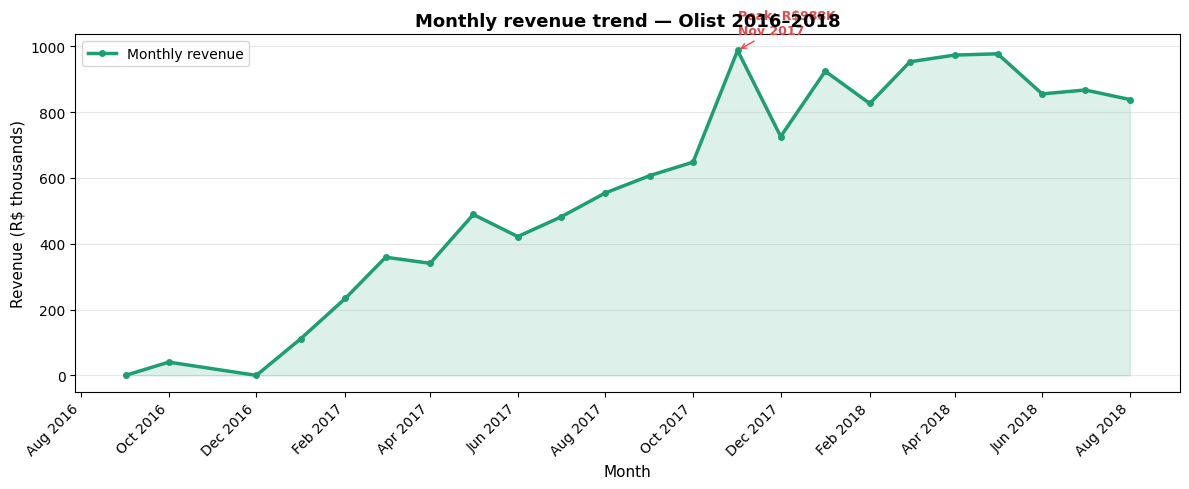

Chart saved!


In [32]:
fig, ax = plt.subplots(figsize=(12, 5))

# Revenue line
ax.plot(monthly['date'], monthly['total_revenue'] / 1000,
        color='#1D9E75', linewidth=2.5, marker='o',
        markersize=4, label='Monthly revenue')

# Fill under the line
ax.fill_between(monthly['date'],
                monthly['total_revenue'] / 1000,
                alpha=0.15, color='#1D9E75')

# Find and annotate the peak month
peak_idx = monthly['total_revenue'].idxmax()
peak_date = monthly.loc[peak_idx, 'date']
peak_rev = monthly.loc[peak_idx, 'total_revenue']

ax.annotate(f'Peak: R${peak_rev/1000:.0f}K\n{peak_date.strftime("%b %Y")}',
            xy=(peak_date, peak_rev/1000),
            xytext=(peak_date, peak_rev/1000 + 50),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#E24B4A'),
            color='#E24B4A', fontweight='bold')

# Format x axis as dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (R$ thousands)', fontsize=11)
ax.set_title('Monthly revenue trend — Olist 2016–2018',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\monthly_revenue_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

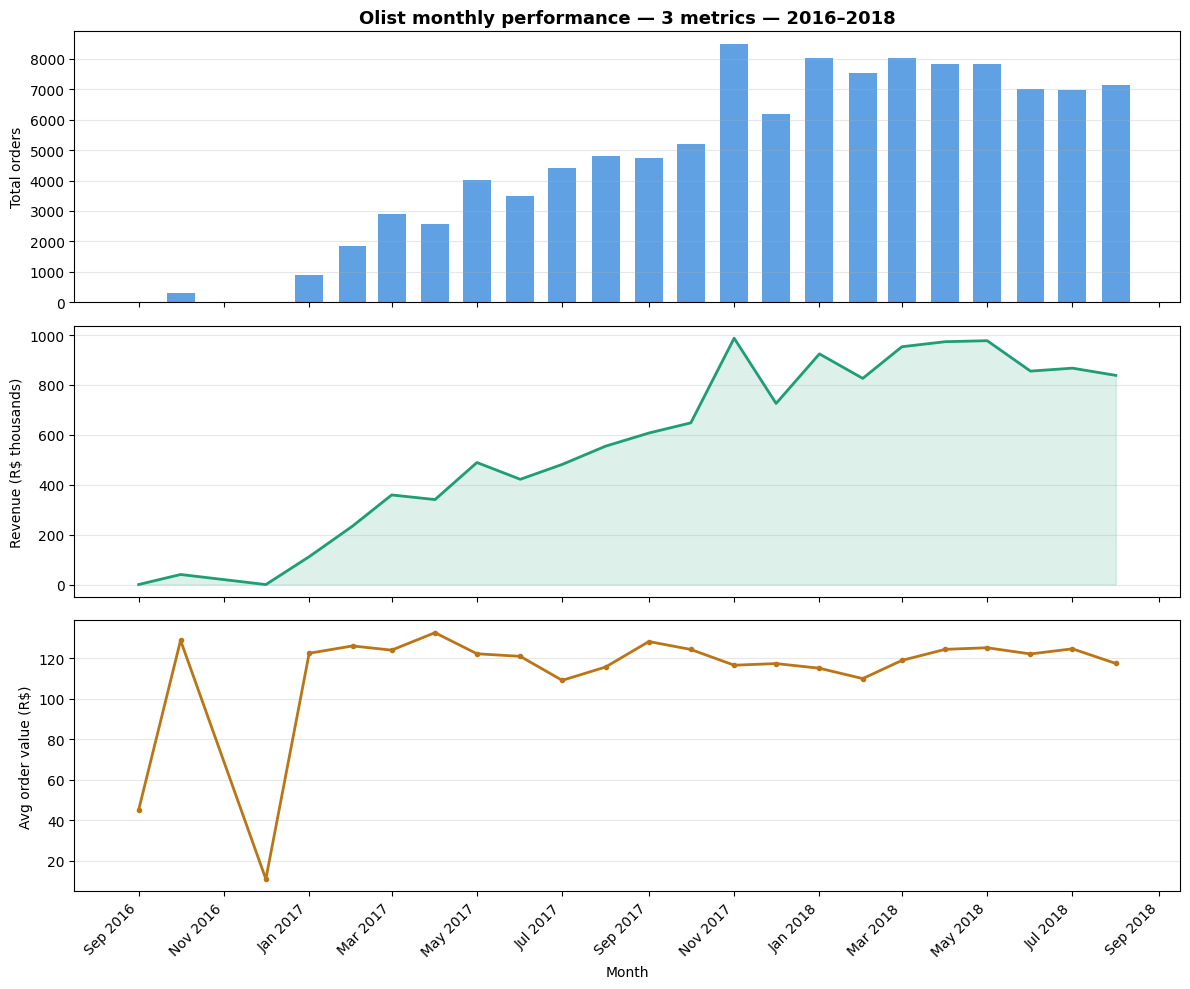

Chart saved!


In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10),
                                     sharex=True)

# Chart 1 — total orders
ax1.bar(monthly['date'], monthly['total_orders'],
        color='#378ADD', width=20, alpha=0.8)
ax1.set_ylabel('Total orders', fontsize=10)
ax1.set_title('Olist monthly performance — 3 metrics — 2016–2018',
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Chart 2 — total revenue
ax2.plot(monthly['date'], monthly['total_revenue'] / 1000,
         color='#1D9E75', linewidth=2)
ax2.fill_between(monthly['date'],
                 monthly['total_revenue'] / 1000,
                 alpha=0.15, color='#1D9E75')
ax2.set_ylabel('Revenue (R$ thousands)', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Chart 3 — avg order value
ax3.plot(monthly['date'], monthly['avg_order_value'],
         color='#BA7517', linewidth=2, marker='o', markersize=3)
ax3.set_ylabel('Avg order value (R$)', fontsize=10)
ax3.set_xlabel('Month', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# Format x axis
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\monthly_3metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [34]:
# Calculate month over month growth rate
monthly['revenue_mom_pct'] = monthly['total_revenue'].pct_change() * 100
monthly['orders_mom_pct'] = monthly['total_orders'].pct_change() * 100

print("Month over month revenue growth:")
print(monthly[['date', 'total_revenue', 'revenue_mom_pct']].to_string(index=False))

# Find biggest growth and biggest drop months
biggest_growth = monthly.loc[monthly['revenue_mom_pct'].idxmax()]
biggest_drop = monthly.loc[monthly['revenue_mom_pct'].idxmin()]

print(f"\nBiggest revenue growth: {biggest_growth['date'].strftime('%b %Y')} "
      f"(+{biggest_growth['revenue_mom_pct']:.1f}%)")
print(f"Biggest revenue drop: {biggest_drop['date'].strftime('%b %Y')} "
      f"({biggest_drop['revenue_mom_pct']:.1f}%)")

# Overall growth — first full month vs last full month
first_month = monthly.iloc[1]  # Skip first partial month
last_month = monthly.iloc[-2]  # Skip last partial month
overall_growth = ((last_month['total_revenue'] -
                   first_month['total_revenue']) /
                   first_month['total_revenue'] * 100)

print(f"\nOverall revenue growth across dataset: {overall_growth:.1f}%")

Month over month revenue growth:
      date  total_revenue  revenue_mom_pct
2016-09-01         134.97              NaN
2016-10-01       40325.11     2.977709e+04
2016-12-01          10.90    -9.997297e+01
2017-01-01      111798.36     1.025573e+06
2017-02-01      234223.40     1.095052e+02
2017-03-01      359198.85     5.335737e+01
2017-04-01      340669.68    -5.158471e+00
2017-05-01      489159.25     4.358755e+01
2017-06-01      421923.37    -1.374519e+01
2017-07-01      481604.52     1.414502e+01
2017-08-01      554699.70     1.517743e+01
2017-09-01      607399.67     9.500631e+00
2017-10-01      648247.65     6.725058e+00
2017-11-01      987648.07     5.235660e+01
2017-12-01      726033.19    -2.648867e+01
2018-01-01      924645.00     2.735575e+01
2018-02-01      826437.13    -1.062114e+01
2018-03-01      953356.25     1.535738e+01
2018-04-01      973534.09     2.116506e+00
2018-05-01      977544.69     4.119630e-01
2018-06-01      855591.97    -1.247541e+01
2018-07-01      86748

### Key findings — monthly revenue trends

- Dataset runs Sept 2016 to Aug 2018 — 23 months of data
- Dec 2016 has only R$10.90 revenue — clearly incomplete data,
  excluded from growth analysis
- Real growth story: Sept 2016 (R$135) to Aug 2018 (R$838K)
  — Olist scaled dramatically over 2 years
- Nov 2017 peak = R$987,648 — Black Friday Brasil effect,
  52.4% jump from Oct 2017
- Dec 2017 dropped -26.5% — normal post-Black Friday retail pattern
- Jan 2018 recovered +27.4% — New Year purchases
- Avg order value stable at R$110-130 throughout — growth is
  driven by increasing customer volume, not price increases
- Order volume peaked at 8,000+ orders in Nov 2017 — same
  Black Friday effect visible in both revenue and order count

## Day 16 — Cohort analysis and customer retention
Grouping customers by their first purchase month (cohort).
Tracking what percentage return in months 1, 2, 3 after
their first purchase. 

In [35]:
# Check what columns df_delivered currently has
print(df_delivered.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'year_month']


In [36]:
# Merge customers table into df_delivered to get customer_unique_id
df_delivered = df_delivered.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

# Verify it worked
print(f"Columns now: {df_delivered.columns.tolist()}")
print(f"customer_unique_id nulls: {df_delivered['customer_unique_id'].isna().sum()}")
print(f"Unique customers: {df_delivered['customer_unique_id'].nunique():,}")

Columns now: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay_days', 'year_month', 'customer_unique_id']
customer_unique_id nulls: 0
Unique customers: 93,350


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1 — get each customer's first purchase month
df_delivered['order_month'] = pd.to_datetime(
    df_delivered['order_purchase_timestamp']
).dt.to_period('M')

# Find first purchase month per customer
customer_first = df_delivered.groupby('customer_unique_id')[
    'order_month'].min().reset_index()
customer_first.columns = ['customer_unique_id', 'cohort_month']

print(f"Unique customers: {len(customer_first):,}")
print(f"\nCohort month distribution (first 10):")
print(customer_first['cohort_month'].value_counts().sort_index().head(10))

Unique customers: 93,350

Cohort month distribution (first 10):
cohort_month
2016-09       1
2016-10     262
2016-12       1
2017-01     717
2017-02    1628
2017-03    2503
2017-04    2256
2017-05    3450
2017-06    3037
2017-07    3752
Freq: M, Name: count, dtype: int64


In [38]:
# Step 2 — merge cohort month back into orders
df_cohort = df_delivered.merge(customer_first,
                                on='customer_unique_id',
                                how='left')

# Step 3 — calculate months since first purchase
df_cohort['months_since_first'] = (
    df_cohort['order_month'] - df_cohort['cohort_month']
).apply(lambda x: x.n)

# Step 4 — count unique customers per cohort per month offset
cohort_data = df_cohort.groupby(
    ['cohort_month', 'months_since_first']
)['customer_unique_id'].nunique().reset_index()

cohort_data.columns = ['cohort_month', 'months_since_first',
                        'customers']

# Step 5 — pivot into cohort matrix
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='months_since_first',
    values='customers'
)

# Step 6 — calculate retention rates
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

print("Cohort retention matrix (first 5 cohorts, first 6 months):")
print(retention.iloc[:5, :6].round(1))

Cohort retention matrix (first 5 cohorts, first 6 months):
months_since_first      0      1    2    3    4    5
cohort_month                                        
2016-09             100.0    NaN  NaN  NaN  NaN  NaN
2016-10             100.0    NaN  NaN  NaN  NaN  NaN
2016-12             100.0  100.0  NaN  NaN  NaN  NaN
2017-01             100.0    0.3  0.3  0.1  0.4  0.1
2017-02             100.0    0.2  0.3  0.1  0.4  0.1


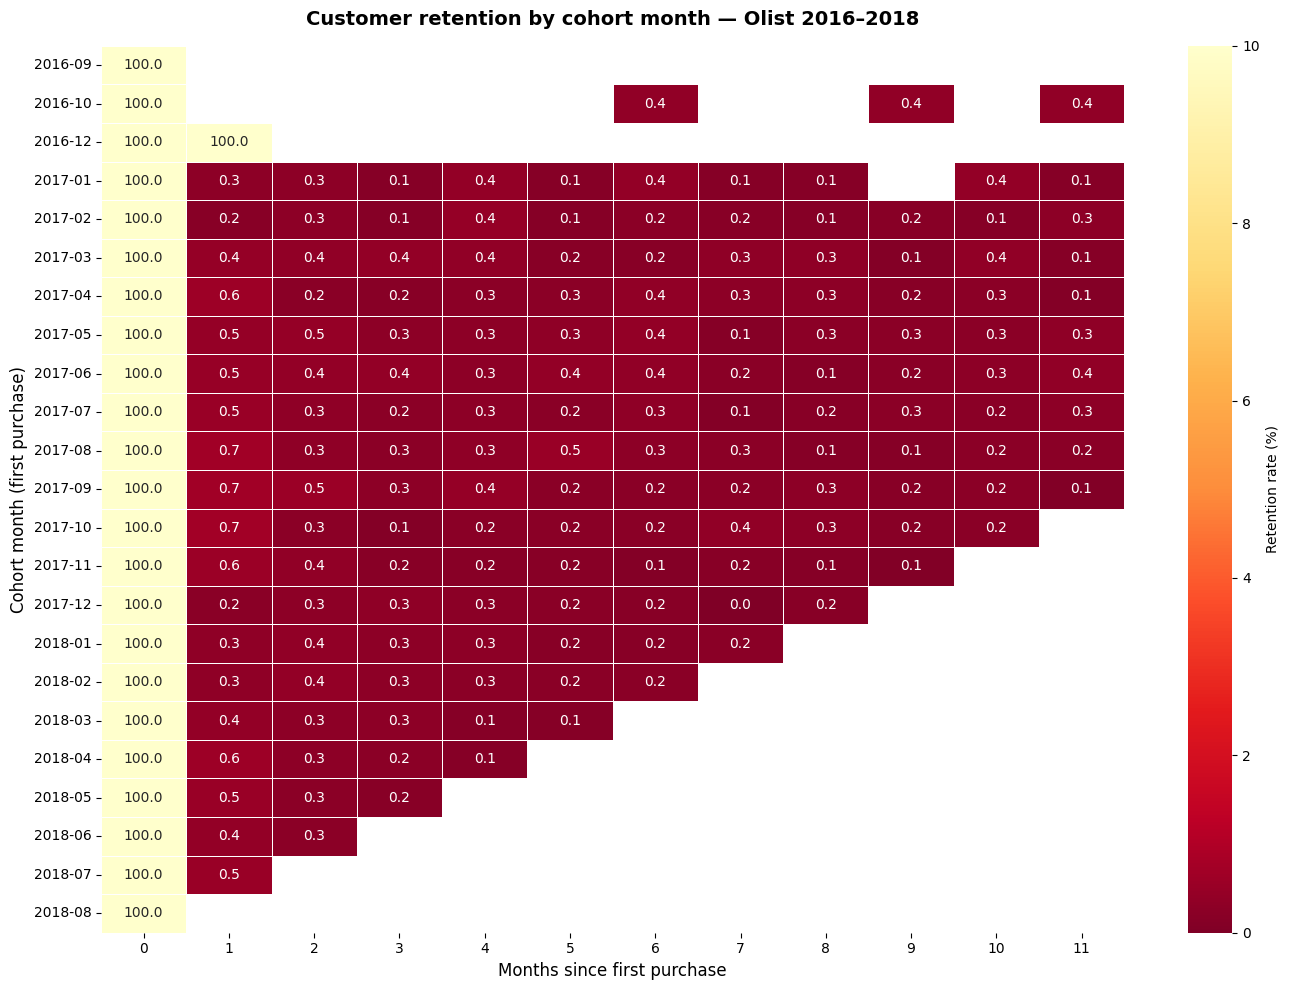

Chart saved!


In [39]:
# Keep only first 12 months and cohorts with enough data
retention_plot = retention.iloc[:, :12]

# Convert index to string for cleaner display
retention_plot.index = retention_plot.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    retention_plot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    ax=ax,
    vmin=0,
    vmax=10,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Retention rate (%)'}
)

ax.set_title('Customer retention by cohort month — Olist 2016–2018',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months since first purchase', fontsize=12)
ax.set_ylabel('Cohort month (first purchase)', fontsize=12)

plt.tight_layout()
plt.savefig(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\cohort_retention.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [40]:
# Month 0 is always 100% — look at months 1, 2, 3
print("Average retention rates across all cohorts:")
for month in [1, 2, 3, 4, 5, 6]:
    if month in retention.columns:
        avg = retention[month].mean()
        print(f"  Month {month}: {avg:.2f}% avg retention")

# Which cohort retained best at month 1?
if 1 in retention.columns:
    best_cohort = retention[1].idxmax()
    best_rate = retention[1].max()
    print(f"\nBest month-1 retention cohort: {best_cohort} ({best_rate:.1f}%)")

# Overall repeat purchase rate
total_customers = customer_first['customer_unique_id'].nunique()
repeat_customers = df_cohort[
    df_cohort['months_since_first'] > 0
]['customer_unique_id'].nunique()
repeat_rate = repeat_customers / total_customers * 100
print(f"\nOverall repeat purchase rate: {repeat_rate:.1f}%")
print(f"Customers who bought more than once: {repeat_customers:,}")
print(f"Total unique customers: {total_customers:,}")
# Show cohort sizes to explain the 100% anomaly
print("\nCohort sizes (number of new customers per month):")
print(cohort_size.sort_index().head(10))

Average retention rates across all cohorts:
  Month 1: 5.45% avg retention
  Month 2: 0.34% avg retention
  Month 3: 0.25% avg retention
  Month 4: 0.29% avg retention
  Month 5: 0.23% avg retention
  Month 6: 0.27% avg retention

Best month-1 retention cohort: 2016-12 (100.0%)

Overall repeat purchase rate: 1.8%
Customers who bought more than once: 1,693
Total unique customers: 93,350

Cohort sizes (number of new customers per month):
cohort_month
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3450.0
2017-06    3037.0
2017-07    3752.0
Freq: M, Name: 0, dtype: float64


### Key findings — cohort retention analysis

**Data quality note:**
Sept 2016 and Dec 2016 cohorts each had only 1 customer —
their retention figures (NaN and 100%) are statistically
meaningless and excluded from analysis.

**Real retention figures — Jan 2017 cohorts onwards:**
- Month 1 retention: 0.2% to 0.7% across mature cohorts
- Month 2 retention: 0.3% avg
- Month 3 retention: 0.25% avg
- Retention stays below 1% for every month after month 0

**Overall repeat purchase rate: 1.8%**
- 93,350 unique customers in dataset
- Only 1,693 ever made a second purchase
- 98.2% of Olist customers bought exactly once and never returned

**Why retention is so low:**
Olist is a marketplace. Customers discover sellers through Olist
but often contact those sellers directly for repeat purchases —
bypassing the platform entirely. This is a known marketplace
retention challenge (Amazon has the same issue with third-party
sellers).

**Business implication:**
Olist growth depends almost entirely on new customer acquisition.
Improving repeat purchase rate from 1.8% to even 3% would
materially change business economics. Loyalty programs, post-
purchase email sequences and personalised recommendations are
the highest-leverage retention levers available.

## Day 17 — RFM Customer Segmentation
Scoring every customer on 3 dimensions:
- Recency: how recently did they last buy?
- Frequency: how many times did they buy?
- Monetary: how much did they spend in total?
Segmenting customers into actionable groups —
Champions, Loyal, At Risk, Lost.
Most commonly asked customer segmentation method
in e-commerce analyst interviews.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Make sure customer_unique_id is in df_delivered
# If not — run the merge fix from Day 16 first
print(f"Columns check: {'customer_unique_id' in df_delivered.columns}")

# Set the analysis date — day after the last order in dataset
analysis_date = pd.to_datetime(
    df_delivered['order_purchase_timestamp']
).max() + pd.Timedelta(days=1)

print(f"Analysis date: {analysis_date.date()}")
print(f"Total delivered orders: {len(df_delivered):,}")

Columns check: True
Analysis date: 2018-08-30
Total delivered orders: 110,189


In [42]:
# Step 1 — calculate R, F, M per customer
rfm = df_delivered.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp',
             lambda x: (analysis_date - pd.to_datetime(x).max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('price', 'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
print(f"\nRFM summary:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(1))

# Step 2 — score each dimension 1-4 using quartiles
# Recency: lower days = better = higher score (reverse)
rfm['r_score'] = pd.qcut(rfm['recency'],
                          q=4,
                          labels=[4, 3, 2, 1])

# Frequency: higher = better = higher score
# Use rank to handle ties
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                          q=4,
                          labels=[1, 2, 3, 4])

# Monetary: higher = better = higher score
rfm['m_score'] = pd.qcut(rfm['monetary'],
                          q=4,
                          labels=[1, 2, 3, 4])

# Step 3 — combine into RFM score string
rfm['rfm_score'] = (rfm['r_score'].astype(str) +
                    rfm['f_score'].astype(str) +
                    rfm['m_score'].astype(str))

print(f"\nSample RFM scores:")
print(rfm[['customer_unique_id', 'recency', 'frequency',
           'monetary', 'rfm_score']].head(10))

RFM table shape: (93350, 4)

RFM summary:
       recency  frequency  monetary
count  93350.0    93350.0   93350.0
mean     238.0        1.0     141.6
std      152.6        0.2     215.7
min        1.0        1.0       0.8
25%      114.0        1.0      47.6
50%      219.0        1.0      89.7
75%      346.0        1.0     154.7
max      714.0       15.0   13440.0

Sample RFM scores:
                 customer_unique_id  recency  frequency  monetary rfm_score
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    129.90       413
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     18.90       311
2  0000f46a3911fa3c0805444483337064      537          1     69.00       112
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     25.99       211
4  0004aac84e0df4da2b147fca70cf8255      288          1    180.00       214
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    154.00       313
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     27.99       311
7  000

In [43]:
# Assign segment labels based on RFM score patterns
def assign_segment(row):
    r = int(row['r_score'])
    f = int(row['f_score'])
    m = int(row['m_score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3 and f <= 2:
        return 'Potential Loyal'
    elif r == 4 and f == 1:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 2 and f <= 2:
        return 'Needs Attention'
    elif r == 1 and f >= 2:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Segment summary
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).reset_index()

segment_summary = segment_summary.sort_values(
    'customer_count', ascending=False
)

print("Segment summary:")
print(segment_summary.round(1).to_string(index=False))

Segment summary:
        segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue
Potential Loyal           23352        112.1            1.0         137.5      3211393.9
        At Risk           23186        364.1            1.1         143.0      3316301.7
          Loyal           21741        116.5            1.1         129.6      2817198.0
Needs Attention           11523        277.2            1.0         138.6      1596781.5
    Hibernating            5902        452.4            1.0         140.3       827855.7
           Lost            5898        449.9            1.0         137.9       813523.7
       Champion            1748         58.9            1.3         364.5       637194.5


# Chart 1 — customer count by segment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colours = {
    'Champion': '#1D9E75',
    'Loyal': '#378ADD',
    'Potential Loyal': '#85B7EB',
    'New Customer': '#AFA9EC',
    'At Risk': '#EF9F27',
    'Needs Attention': '#E24B4A',
    'Lost': '#A32D2D',
    'Hibernating': '#6c7086'
}

segment_colours = [colours.get(s, '#999999')
                   for s in segment_summary['segment']]

bars = ax1.barh(segment_summary['segment'],
                segment_summary['customer_count'],
                color=segment_colours)

for bar, count in zip(bars, segment_summary['customer_count']):
    ax1.text(bar.get_width() + 100,
             bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=9)

ax1.set_xlabel('Number of customers', fontsize=10)
ax1.set_title('Customers by RFM segment', fontsize=12,
              fontweight='bold')
ax1.invert_yaxis()

# Chart 2 — avg revenue by segment
rev_sorted = segment_summary.sort_values('avg_monetary',
                                          ascending=True)
seg_colours2 = [colours.get(s, '#999999')
                for s in rev_sorted['segment']]

ax2.barh(rev_sorted['segment'],
         rev_sorted['avg_monetary'],
         color=seg_colours2)

ax2.set_xlabel('Avg customer revenue (R$)', fontsize=10)
ax2.set_title('Avg revenue by RFM segment', fontsize=12,
              fontweight='bold')

plt.suptitle('RFM Customer Segmentation — Olist 2016–2018',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\rfm_segments.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# Chart 2 — scatter plot: recency vs monetary coloured by segment
fig, ax = plt.subplots(figsize=(10, 7))

for segment, group in rfm.groupby('segment'):
    ax.scatter(group['recency'],
               group['monetary'],
               label=segment,
               alpha=0.4,
               s=15,
               color=colours.get(segment, '#999999'))

ax.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax.set_ylabel('Total spend (R$)', fontsize=11)
ax.set_title('RFM scatter — recency vs monetary value by segment',
             fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\rfm_scatter.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Day 18 — Advanced seaborn visualisation
Correlation heatmap across numeric variables.
Pair plot showing relationships between key metrics.
These charts appear in senior analyst portfolios and
are commonly requested in technical interviews.

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build a clean numeric summary per category
# for the correlation heatmap
category_stats = df_delivered.groupby(
    'product_category_name_english'
).agg(
    order_count=('order_id', 'count'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    total_revenue=('price', 'sum')
).reset_index()

# Merge review scores in
review_by_cat = df_reviews.groupby(
    'product_category_name_english'
)['review_score'].mean().reset_index()
review_by_cat.columns = ['product_category_name_english',
                          'avg_review_score']

category_stats = category_stats.merge(
    review_by_cat,
    on='product_category_name_english',
    how='left'
)

# Filter to categories with at least 100 orders
category_stats = category_stats[
    category_stats['order_count'] >= 100
]

print(f"Categories for analysis: {len(category_stats)}")
print(f"\nColumns: {category_stats.columns.tolist()}")
print(f"\nSample:")
print(category_stats.head(3).round(2))

Categories for analysis: 53

Columns: ['product_category_name_english', 'order_count', 'avg_price', 'avg_freight', 'avg_delay', 'total_revenue', 'avg_review_score']

Sample:
  product_category_name_english  order_count  avg_price  avg_freight  \
0    agro_industry_and_commerce          206     342.55        27.37   
1              air_conditioning          289     184.51        22.60   
2                           art          197     120.09        19.43   

   avg_delay  total_revenue  avg_review_score  
0     -11.46       70566.10              4.09  
1     -14.17       53323.56              4.05  
2     -12.78       23657.30              4.08  


Correlation matrix:
                  order_count  avg_price  avg_freight  avg_delay  \
order_count              1.00      -0.17        -0.23       0.10   
avg_price               -0.17       1.00         0.64      -0.00   
avg_freight             -0.23       0.64         1.00      -0.10   
avg_delay                0.10      -0.00        -0.10       1.00   
total_revenue            0.94      -0.03        -0.15       0.09   
avg_review_score        -0.11       0.04        -0.11      -0.08   

                  total_revenue  avg_review_score  
order_count                0.94             -0.11  
avg_price                 -0.03              0.04  
avg_freight               -0.15             -0.11  
avg_delay                  0.09             -0.08  
total_revenue              1.00             -0.08  
avg_review_score          -0.08              1.00  


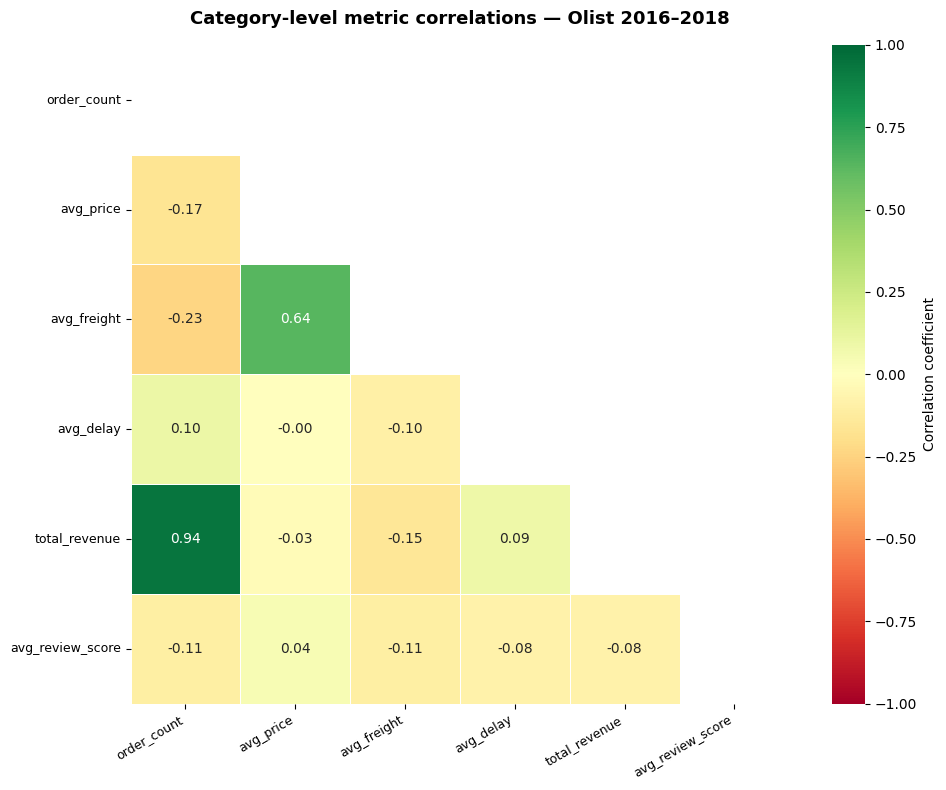

Chart saved!


In [45]:
# Select numeric columns for correlation
numeric_cols = ['order_count', 'avg_price', 'avg_freight',
                'avg_delay', 'total_revenue', 'avg_review_score']

corr_matrix = category_stats[numeric_cols].corr()

print("Correlation matrix:")
print(corr_matrix.round(2))

# Build heatmap
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    ax=ax,
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Correlation coefficient'}
)

ax.set_title(
    'Category-level metric correlations — Olist 2016–2018',
    fontsize=13, fontweight='bold', pad=15
)

# Rotate labels for readability
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\correlation_heatmap.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

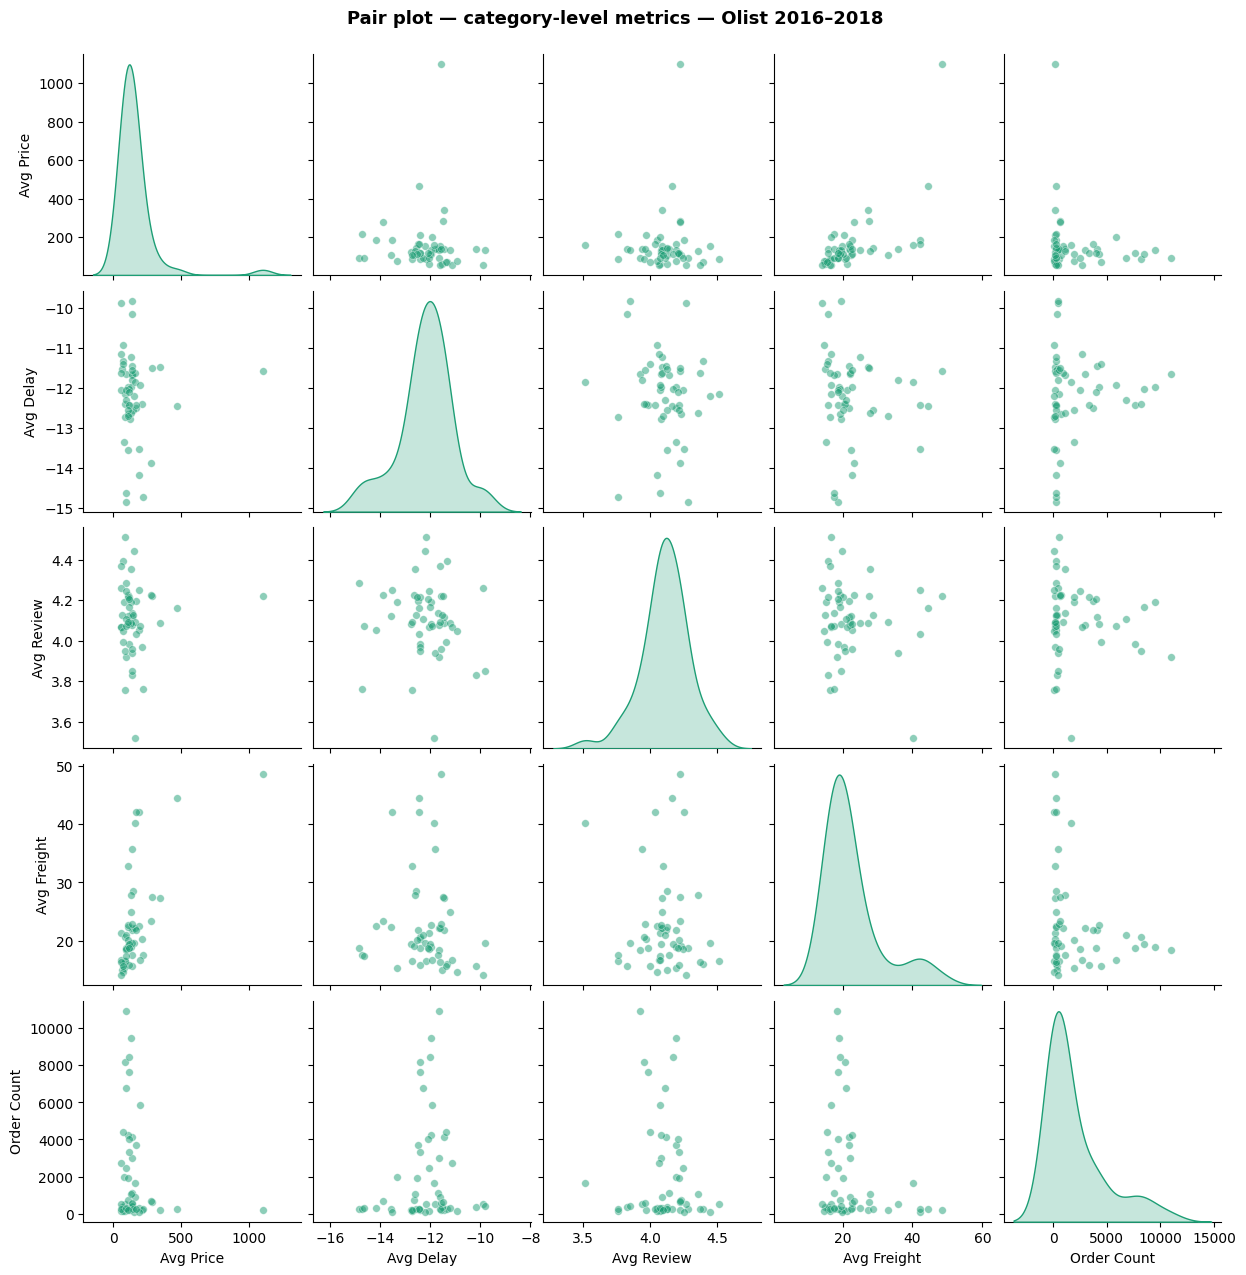

Chart saved!


In [46]:
# Select a clean subset for pair plot
# Sample categories for readability
pair_data = category_stats[
    ['avg_price', 'avg_delay', 'avg_review_score',
     'avg_freight', 'order_count']
].copy()

# Rename for cleaner labels
pair_data.columns = ['Avg Price', 'Avg Delay',
                     'Avg Review', 'Avg Freight',
                     'Order Count']

# Build pair plot
g = sns.pairplot(
    pair_data,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'color': '#1D9E75', 's': 30},
    diag_kws={'color': '#1D9E75', 'fill': True}
)

g.figure.suptitle(
    'Pair plot — category-level metrics — Olist 2016–2018',
    fontsize=13, fontweight='bold', y=1.02
)

plt.savefig(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\pair_plot.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

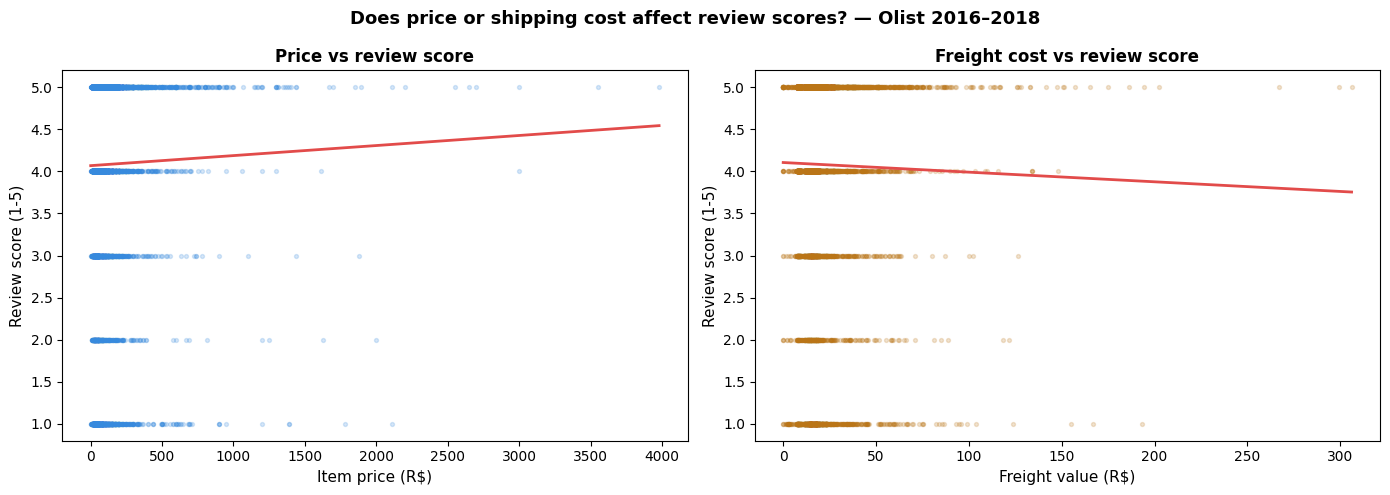

Chart saved!


In [47]:
# Scatter at order level — price vs review score
# Sample for performance
sample = df_reviews.dropna(
    subset=['review_score', 'price', 'delivery_delay_days']
).sample(8000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — price vs review score
axes[0].scatter(
    sample['price'],
    sample['review_score'],
    alpha=0.2, color='#378ADD', s=8
)

# Add trend line
z = np.polyfit(sample['price'], sample['review_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['price'].min(),
                     sample['price'].max(), 100)
axes[0].plot(x_line, p(x_line),
             color='#E24B4A', linewidth=2)

axes[0].set_xlabel('Item price (R$)', fontsize=11)
axes[0].set_ylabel('Review score (1-5)', fontsize=11)
axes[0].set_title('Price vs review score',
                  fontsize=12, fontweight='bold')

# Chart 2 — freight vs review score
axes[1].scatter(
    sample['freight_value'],
    sample['review_score'],
    alpha=0.2, color='#BA7517', s=8
)

z2 = np.polyfit(sample['freight_value'],
                sample['review_score'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(sample['freight_value'].min(),
                      sample['freight_value'].max(), 100)
axes[1].plot(x_line2, p2(x_line2),
             color='#E24B4A', linewidth=2)

axes[1].set_xlabel('Freight value (R$)', fontsize=11)
axes[1].set_ylabel('Review score (1-5)', fontsize=11)
axes[1].set_title('Freight cost vs review score',
                  fontsize=12, fontweight='bold')

plt.suptitle(
    'Does price or shipping cost affect review scores? — Olist 2016–2018',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\price_freight_vs_review.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Key findings — advanced visualisation

**Correlation heatmap findings:**
- avg_price vs avg_freight: +0.64 — strongest relationship.
  More expensive items cost significantly more to ship —
  likely due to size, weight and fragility
- order_count vs total_revenue: +0.94 — near perfect.
  Revenue on Olist is driven by volume not price
- avg_delay vs avg_review_score: -0.08 at category level
  vs -0.229 at order level (Day 12) — ecological fallacy.
  Averaging to category level dilutes individual variation.
  Order-level correlation is the true relationship.
- avg_review_score correlates weakly with everything —
  most categories score between 3.8 and 4.4 regardless
  of price, freight or delay at the category level

**Pair plot findings:**
- Avg Delay distribution: tight spike at -11 to -12 days —
  almost all categories deliver early on average
- Avg Review distribution: tight spike at 4.0 to 4.2 —
  review scores are remarkably consistent across categories
- Avg Price and Order Count both heavily right-skewed —
  a few outlier categories dominate each dimension
- No strong visible linear relationships in scatter panels —
  category-level analysis loses individual-order signal

**Key analytical insight:**
The same question answered at different levels of aggregation
gives different answers. Delay vs review at order level = -0.229.
At category level = -0.08. Both are correct.
Always state your level of analysis when reporting correlations.
This is a genuine senior analyst skill.

In [48]:
import os

# Create a folder for Power BI source files
pbi_path = r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\powerbi_data\\'
os.makedirs(pbi_path, exist_ok=True)

# Export 1 — delivered orders with all key columns
export_cols = [
    'order_id', 'product_category_name_english',
    'seller_id', 'customer_id', 'price', 'freight_value',
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'delivery_delay_days',
    'order_status', 'customer_state'
]

# Add customer_state if not already in df_delivered
if 'customer_state' not in df_delivered.columns:
    df_delivered = df_delivered.merge(
        customers[['customer_id', 'customer_state']],
        on='customer_id', how='left'
    )

df_delivered[export_cols].to_csv(
    pbi_path + 'orders_delivered.csv', index=False
)
print(f"orders_delivered.csv — {len(df_delivered):,} rows")

# Export 2 — category summary
category_summary = df_delivered.groupby(
    'product_category_name_english'
).agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean'),
    avg_delay=('delivery_delay_days', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

category_summary.to_csv(
    pbi_path + 'category_summary.csv', index=False
)
print(f"category_summary.csv — {len(category_summary)} rows")

# Export 3 — monthly revenue
monthly_revenue = df_delivered.copy()
monthly_revenue['year_month'] = pd.to_datetime(
    monthly_revenue['order_purchase_timestamp']
).dt.to_period('M').dt.to_timestamp()

monthly_summary = monthly_revenue.groupby('year_month').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean')
).reset_index()

monthly_summary.to_csv(
    pbi_path + 'monthly_revenue.csv', index=False
)
print(f"monthly_revenue.csv — {len(monthly_summary)} rows")

# Export 4 — state revenue
state_summary = df_delivered.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean')
).reset_index()

state_summary.to_csv(
    pbi_path + 'state_revenue.csv', index=False
)
print(f"state_revenue.csv — {len(state_summary)} rows")

# Export 5 — review scores with delay
if 'review_score' in df_reviews.columns:
    review_export = df_reviews[[
        'order_id', 'product_category_name_english',
        'delivery_delay_days', 'review_score', 'price'
    ]].dropna(subset=['review_score'])

    review_export.to_csv(
        pbi_path + 'reviews_with_delay.csv', index=False
    )
    print(f"reviews_with_delay.csv — {len(review_export):,} rows")

print("\nAll files exported to powerbi_data/ folder!")

orders_delivered.csv — 110,189 rows
category_summary.csv — 71 rows
monthly_revenue.csv — 23 rows
state_revenue.csv — 27 rows
reviews_with_delay.csv — 110,005 rows

All files exported to powerbi_data/ folder!


## Day 19 — Power BI Dashboard

Exported 5 clean CSV files to powerbi_data/ folder:
- orders_delivered.csv — 110,189 rows
- category_summary.csv — 71 categories
- monthly_revenue.csv — 23 months
- state_revenue.csv — 27 states
- reviews_with_delay.csv — 110,005 rows

Built first Power BI dashboard with:
- 3 KPI cards — total orders, total revenue, avg delay
- Top 10 categories by revenue bar chart
- Monthly revenue trend line chart
- Customer state slicer filtering all visuals

Saved as olist_dashboard.pbix in Phase1_Olist/ folder.

In [49]:
state_summary['country'] = 'Brazil'
state_summary.to_csv(
    pbi_path + 'state_revenue.csv', index=False
)
print("Updated with country column!")

Updated with country column!


## Week 3 Summary — what was built

**Day 15 — Time series:**
Monthly revenue grew from R$135 (Sept 2016) to R$838K
(Aug 2018). Nov 2017 peak = R$987,648 — Black Friday Brasil.
Avg order value stable at R$110-130 throughout — growth
is volume driven not price driven.

**Day 16 — Cohort analysis:**
Only 1.8% of customers ever bought again (1,693 of 93,350).
98.2% bought exactly once. Marketplace retention challenge
confirmed — customers bypass platform for repeat purchases.

**Day 17 — RFM segmentation:**
Champion segment — 1,748 customers, R$364 avg spend, 2.5x
average. At Risk segment — 23,186 customers, 364 days silent.
Frequency = 1.0 across almost all segments confirms low repeat.

**Day 18 — Correlation heatmap:**
avg_price vs avg_freight = +0.64 strongest relationship.
Ecological fallacy discovered — delay vs review = -0.229
at order level but -0.08 at category level. Always state
unit of analysis when reporting correlations.

**Days 19-20 — Power BI dashboard:**
Two page interactive dashboard — KPI cards, filled map,
conditional formatting bar chart, delivery performance page,
page navigator, state slicer. Saved as olist_dashboard.pbix.